In [221]:
import os
import yaml
from dotenv import load_dotenv
from typing import Annotated, TypedDict, Any, List, Literal
from langchain_core.messages import HumanMessage, AnyMessage, AIMessage, SystemMessage
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq

In [222]:
env_path = r"D:\common_credentials\.env"
load_dotenv(dotenv_path=env_path)

True

In [223]:
with open("../config.yml", "r") as yml_file:
    yml_config= yaml.safe_load(yml_file)
    yml_file.close()
print(yml_config['GroqModels']["Inferencing_Models"]['text_models'])

['distil-whisper-large-v3-en', 'gemma2-9b-it', 'llama-3.3-70b-versatile', 'llama-3.1-8b-instant', 'whisper-large-v3-turbo', 'deepseek-r1-distill-llama-70b']


In [224]:
llm= ChatGroq(model='llama-3.1-8b-instant')

## Pydancic Classes

In [225]:
# class multiply_class(BaseModel):
#     a: int
#     b: int

# def multiply(input:multiply_class) -> int:
#     """
#     Multiplies two integers, 'a' and 'b' from the provided input model.
    
#     Args:
#     - inputs (MultiplyInput): A model instance containing two integers, 'a' and 'b'.
    
#     Returns:
#     - int: The result of adding 'a' and 'b'.
#     """
#     return input.a * input.b

# inputs = multiply_class(a=3, b=5)
# result = multiply(inputs)
# result

# Functions/ Tools

In [226]:
from langchain_community.tools import tool
tool

<function langchain_core.tools.convert.tool(name_or_callable: Union[str, Callable, NoneType] = None, runnable: Optional[langchain_core.runnables.base.Runnable] = None, *args: Any, return_direct: bool = False, args_schema: Optional[type] = None, infer_schema: bool = True, response_format: Literal['content', 'content_and_artifact'] = 'content', parse_docstring: bool = False, error_on_invalid_docstring: bool = True) -> Union[langchain_core.tools.base.BaseTool, Callable[[Union[Callable, langchain_core.runnables.base.Runnable]], langchain_core.tools.base.BaseTool]]>

In [227]:
def multiply(a:int, b:int) -> int:
    """ Multiply a and b
        Args:
            a: int
            b: int
        returns multiplication of a and b in integer format
    """
    return a * b

def addition(a:int, b:int) -> int:
    """ addition of two integeres
    Args:
        first integer a: int 
        second integer b: int
    Returns:
       int: addition of two integeres "a" and "b" """
    return a + b 

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

#defining the llm model
model_id5= "deepseek-r1-distill-llama-70b"
llm = ChatGroq(model=model_id5)

#tools
tools= [multiply, addition, divide]
#Bind llms with tools 
llm_withTools= llm.bind_tools(tools, parallel_tool_calls=False)
llm_withTools

RunnableBinding(bound=ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x0000019D75631990>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000019D75632FD0>, model_name='deepseek-r1-distill-llama-70b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiply a and b\nArgs:\n    a: int\n    b: int\nreturns multiplication of a and b in integer format', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'addition', 'description': 'addition of two integeres\nArgs:\n    first integer a: int \n    second integer b: int\nReturns:\n   int: addition of two integeres "a" and "b" ', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'functi

In [228]:
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, START, END

#Define the graph state (key: list of anymessage, value will be the new added messages)
class Graphstate(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]


In [250]:
#system prompt
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

sys_prompt= SystemMessage(content="""You are an expert helpful assistant who tasked with performing arithmetic on a set of inputs, you must use provided tools for operations""")

def assistant_llm(state:Graphstate):
    """Large language models with tools, aligned with perticular system prompt"""
    response= llm_withTools.invoke([sys_prompt]+state["messages"])
    return {"messages": response}


#graph state: state 
builder= StateGraph(Graphstate)
builder.add_node("assistant", assistant_llm)
builder.set_entry_point("assistant")
builder.add_node("tools", ToolNode(tools))

# edges 
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")
# builder.add_edge("assistant", END)

#compiling
memory=MemorySaver()
graph= builder.compile(checkpointer= memory)

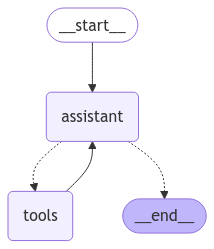

In [251]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [256]:
config={"configurable":{"thread_id":"1"}}
messages = [HumanMessage(content="Add 3 and 4.")]

# Run
messages = graph.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  addition (call_cnkp)
 Call ID: call_cnkp
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: addition

7
================================== Ai Message ==================================
Tool Calls:
  addition (call_fr0k)
 Call ID: call_fr0k
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: addition

7
================================== Ai Message ==================================
Tool Calls:
  addition (call_sx3d)
 Call ID: call_sx3d
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: addition

7
================================== Ai Message ==================================

<tool_call>{"id":"call_7q9p","name":"add

In [257]:
config={"configurable":{"thread_id":"1"}}
messages = [HumanMessage(content="now add 7 in this")]

# Run
messages = graph.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  addition (call_cnkp)
 Call ID: call_cnkp
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: addition

7
================================== Ai Message ==================================
Tool Calls:
  addition (call_fr0k)
 Call ID: call_fr0k
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: addition

7
================================== Ai Message ==================================
Tool Calls:
  addition (call_sx3d)
 Call ID: call_sx3d
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: addition

7
================================== Ai Message ==================================

<tool_call>{"id":"call_7q9p","name":"add

In [258]:
config={"configurable":{"thread_id":"1"}}
messages = [HumanMessage(content="What is the answer?")]

# Run
messages = graph.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  addition (call_cnkp)
 Call ID: call_cnkp
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: addition

7
================================== Ai Message ==================================
Tool Calls:
  addition (call_fr0k)
 Call ID: call_fr0k
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: addition

7
================================== Ai Message ==================================
Tool Calls:
  addition (call_sx3d)
 Call ID: call_sx3d
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: addition

7
================================== Ai Message ==================================

<tool_call>{"id":"call_7q9p","name":"add

In [259]:
config={"configurable":{"thread_id":"1"}}
messages = [HumanMessage(content="can you tell me what task we did earlier??")]

# Run
messages = graph.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  addition (call_cnkp)
 Call ID: call_cnkp
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: addition

7
================================== Ai Message ==================================
Tool Calls:
  addition (call_fr0k)
 Call ID: call_fr0k
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: addition

7
================================== Ai Message ==================================
Tool Calls:
  addition (call_sx3d)
 Call ID: call_sx3d
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: addition

7
================================== Ai Message ==================================

<tool_call>{"id":"call_7q9p","name":"add